# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [1]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

OUTPUT_DIR = Path("pruning_outputs_1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-07-15 12:33:35.658119: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-15 12:33:35.660613: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-15 12:33:35.687724: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-15 12:33:35.687754: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-15 12:33:35.687773: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

Python executable: /home/zachh/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [3]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    root_dir = Path(root_dir)
    X_train = np.loadtxt(root_dir / "train" / "X_train.txt").astype("float32")
    y_train = np.loadtxt(root_dir / "train" / "y_train.txt").astype("int32")
    X_test = np.loadtxt(root_dir / "test" / "X_test.txt").astype("float32")
    y_test = np.loadtxt(root_dir / "test" / "y_test.txt").astype("int32")

    return X_train, (y_train - 1), X_test, (y_test - 1)

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(class_names)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {num_features}")
print(f"Number of classes: {num_classes}")

Training data shape: (7352, 561)
Test data shape: (2947, 561)
Number of features: 561
Number of classes: 6


## 4. Quick Inspection

In [4]:
label_counts = np.bincount(y_train)

# Construct the summary table
dataset_summary = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": label_counts
})

print(dataset_summary)

   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [5]:
def build_baseline_model(input_dim, num_classes):
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    inputs = keras.Input(shape=(input_dim,), name="input_layer")
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name="output_layer")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


2026-07-15 12:33:40.609006: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-15 12:33:40.803189: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 561)]             0         
                                                                 
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 output_layer (Dense)        (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [6]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, 
    y_train, 
    validation_split=0.2, 
    epochs=40, 
    batch_size=64, 
    callbacks=callbacks
)

Epoch 1/40
92/92 [==============================] - 1s 7ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 5ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 4ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 5ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves

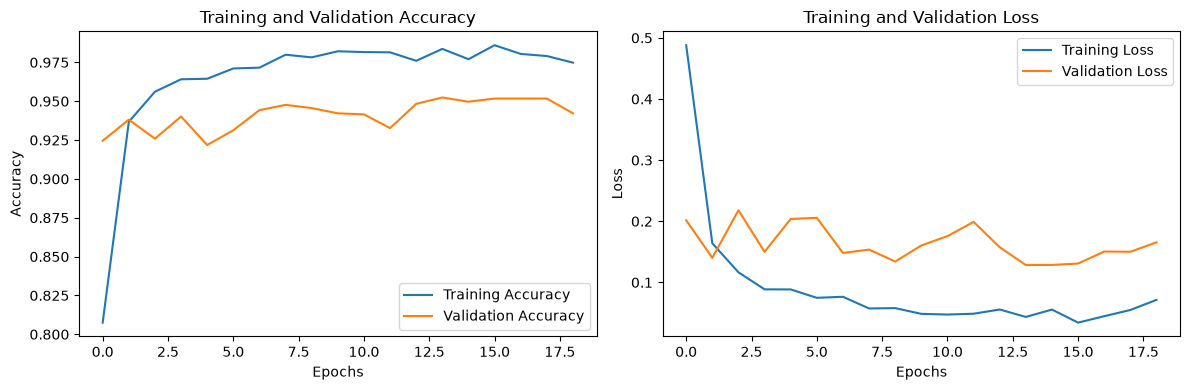

In [7]:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot Accuracy
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Loss
ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 2ms/step
Test Accuracy: 0.9352

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       496
           1       0.95      0.93      0.94       471
           2       0.94      0.94      0.94       420
           3       0.88      0.92      0.90       491
           4       0.90      0.88      0.89       532
           5       1.00      0.97      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



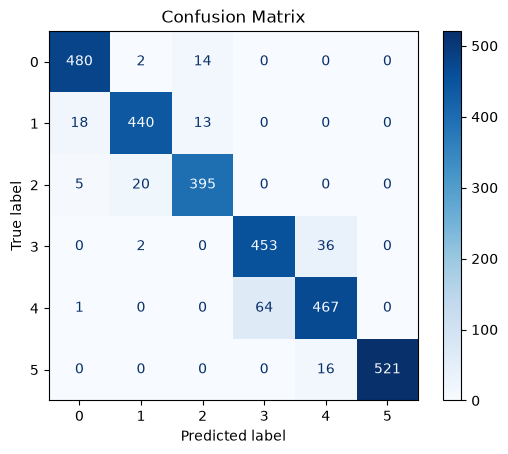

In [8]:
# 1. Obtain predicted probabilities on X_test
y_pred_probs = baseline_model.predict(X_test)
# 2. Convert them to class predictions using argmax
y_pred = np.argmax(y_pred_probs, axis=1)
# 3. Compute test accuracy
test_accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
# 4. Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# 5. Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [9]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for i in range(300):
        sample = X_train[i:i+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = (x / input_scale) + input_zero_point
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)

    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    # Attach representative_dataset_gen
    converter.representative_dataset = representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Set inference_input_type and inference_output_type to tf.int8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    # Return the converted model
    return converter.convert()


## 8. Convert the Baseline Model to TensorFlow Lite

In [10]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# Convert the baseline model into:
# - FP32 TFLite
# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

conversion_tasks = [
    ("fp32", convert_to_tflite_fp32(baseline_model)),
]

results = []

# Process, save, and evaluate each model
for name, model_content in conversion_tasks:
    filename = os.path.join(OUTPUT_DIR, f"mnist_model_{name}.tflite")
    
    # Save model
    size_kb = save_binary_model(model_content, filename)
    
    # Evaluate model
    acc, _ = evaluate_tflite_model(model_content, X_test, y_test)
    
    results.append({
        "Model": name.upper(),
        "Size (KB)": size_kb,
        "Accuracy": acc
    })

summary_df = pd.DataFrame(results)
print(summary_df)

INFO:tensorflow:Assets written to: /tmp/tmpmy09yhfk/assets


INFO:tensorflow:Assets written to: /tmp/tmpmy09yhfk/assets
2026-07-15 12:33:51.672251: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 12:33:51.672296: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.


  Model   Size (KB)  Accuracy
0  FP32  726.664062  0.935188


2026-07-15 12:33:51.672522: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpmy09yhfk
2026-07-15 12:33:51.673333: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 12:33:51.673346: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpmy09yhfk
2026-07-15 12:33:51.676618: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-15 12:33:51.677235: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 12:33:51.715318: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpmy09yhfk
2026-07-15 12:33:51.723774: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success: OK. Took 51248 microseconds.
2026-07-15 12:33:51.735919: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR cr

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [11]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs
    )
}

# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.
pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)

pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks
pruning_history = pruned_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)


Epoch 1/12
92/92 [==============================] - 2s 7ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1663 - accuracy: 0.9367 - val_loss: 0.1592 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1311 - accuracy: 0.9498 - val_loss: 0.2181 - val_accuracy: 0.9279
Epoch 4/12
92/92 [==============================] - 1s 6ms/step - loss: 0.0919 - accuracy: 0.9691 - val_loss: 0.1689 - val_accuracy: 0.9320
Epoch 5/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1259 - accuracy: 0.9515 - val_loss: 0.1484 - val_accuracy: 0.9395
Epoch 6/12
92/92 [==============================] - 0s 5ms/step - loss: 0.1224 - accuracy: 0.9577 - val_loss: 0.1762 - val_accuracy: 0.9354
Epoch 7/12
92/92 [==============================] - 0s 5ms/step - loss: 0.2871 - accuracy: 0.9294 - val_loss: 0.1576 - val_accuracy: 0.9388
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [12]:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.
# 1 & 2. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.

pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, os.path.join(OUTPUT_DIR, "pruned_with_mask_fp32.tflite"))
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)

# 3. Strip the pruning wrappers using strip_pruning(...).
stripped_model = strip_pruning(pruned_model)

# 4 & 5. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, os.path.join(OUTPUT_DIR, "stripped_sparse_fp32.tflite"))
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

INFO:tensorflow:Assets written to: /tmp/tmpahij83_y/assets


INFO:tensorflow:Assets written to: /tmp/tmpahij83_y/assets
2026-07-15 12:33:59.668630: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 12:33:59.668679: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 12:33:59.668827: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpahij83_y
2026-07-15 12:33:59.670958: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 12:33:59.670977: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpahij83_y
2026-07-15 12:33:59.676669: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 12:33:59.720067: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpahij83_y
2026-07-15 12:33:59.734425: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmprk0mlinl/assets


INFO:tensorflow:Assets written to: /tmp/tmprk0mlinl/assets
2026-07-15 12:34:01.158913: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 12:34:01.158965: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 12:34:01.159119: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmprk0mlinl
2026-07-15 12:34:01.159597: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 12:34:01.159605: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmprk0mlinl
2026-07-15 12:34:01.160718: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 12:34:01.173256: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmprk0mlinl
2026-07-15 12:34:01.178117: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 11. Part I Comparison: Accuracy and Model Size

In [13]:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

part1_comparison = pd.DataFrame([
    {"Model": "Baseline FP32", "Format": "TFLite", "Test Accuracy": summary_df.iloc[0]["Accuracy"], "Model Size (KB)": summary_df.iloc[0]["Size (KB)"]},
    {"Model": "Pruned FP32 (With Mask)", "Format": "TFLite", "Test Accuracy": pruned_with_mask_acc, "Model Size (KB)": pruned_with_mask_size_kb},
    {"Model": "Stripped Sparse FP32", "Format": "TFLite", "Test Accuracy": stripped_sparse_acc, "Model Size (KB)": stripped_sparse_size_kb}
])
print(part1_comparison)


                     Model  Format  Test Accuracy  Model Size (KB)
0            Baseline FP32  TFLite       0.935188       726.664062
1  Pruned FP32 (With Mask)  TFLite       0.919240      1454.082031
2     Stripped Sparse FP32  TFLite       0.919240       338.738281


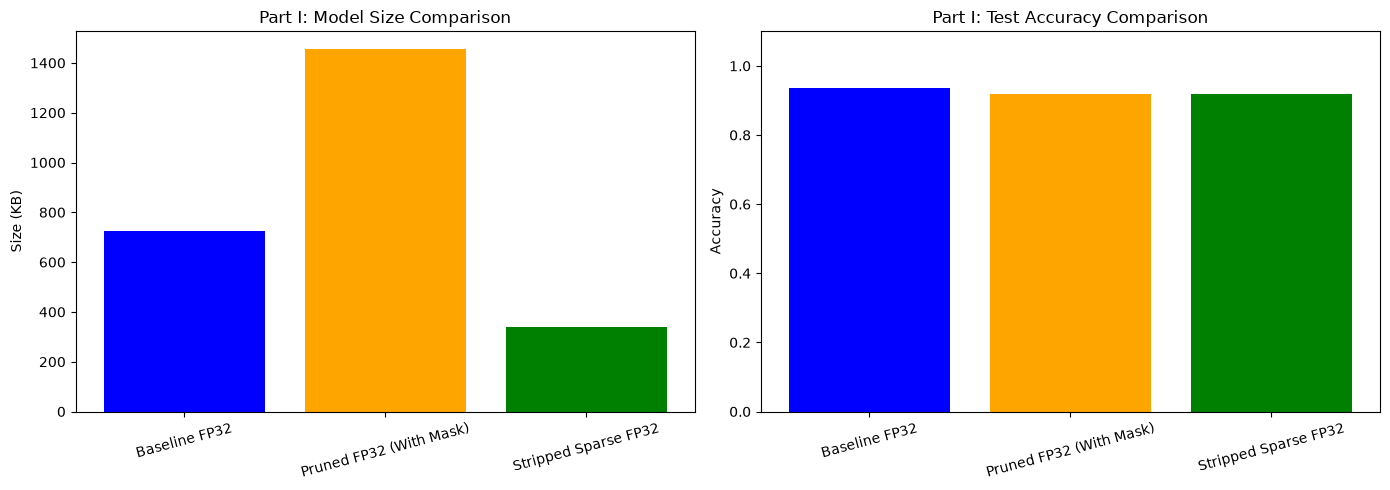

In [14]:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# Plot bar charts of the Part I model sizes and test accuracies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Model Sizes
ax1.bar(part1_comparison["Model"], part1_comparison["Model Size (KB)"], color=['blue', 'orange', 'green'])
ax1.set_title("Part I: Model Size Comparison")
ax1.set_ylabel("Size (KB)")
ax1.tick_params(axis='x', rotation=15)

# Accuracies
ax2.bar(part1_comparison["Model"], part1_comparison["Test Accuracy"], color=['blue', 'orange', 'green'])
ax2.set_title("Part I: Test Accuracy Comparison")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model


Classification Report (Stripped Sparse FP32):
                    precision    recall  f1-score   support

           WALKING     0.9167    0.9536    0.9348       496
  WALKING_UPSTAIRS     0.9405    0.9066    0.9232       471
WALKING_DOWNSTAIRS     0.9167    0.9167    0.9167       420
           SITTING     0.9568    0.8126    0.8789       491
          STANDING     0.8172    0.9662    0.8854       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9192      2947
         macro avg     0.9246    0.9179    0.9190      2947
      weighted avg     0.9244    0.9192    0.9195      2947



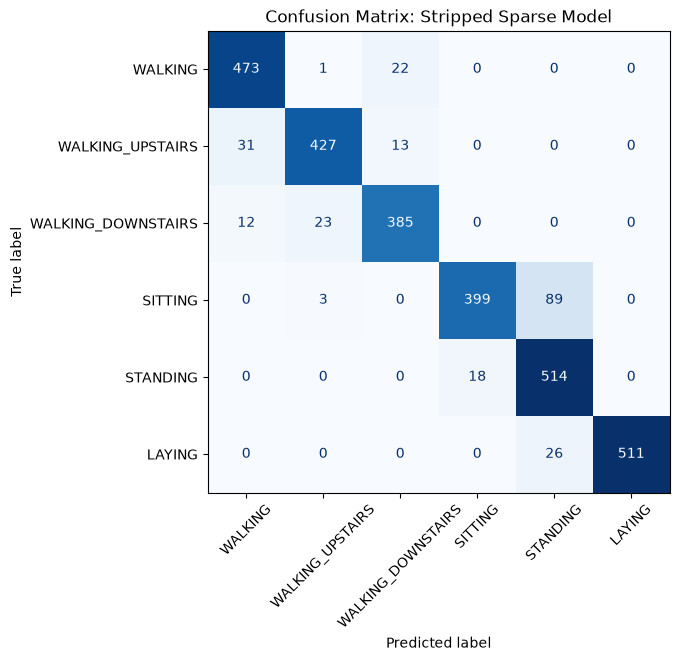

In [15]:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# Plot and print metrics for the stripped sparse TFLite model
print("\nClassification Report (Stripped Sparse FP32):")
print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

cm_sparse = confusion_matrix(y_test, stripped_sparse_preds)
disp_sparse = ConfusionMatrixDisplay(confusion_matrix=cm_sparse, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_sparse.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix: Stripped Sparse Model")
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [16]:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# 1 & 2. Convert the pruned model with mask using Float16
converter_mask_f16 = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter_mask_f16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_mask_f16.target_spec.supported_types = [tf.float16]
pruned_f16_with_mask_tflite = converter_mask_f16.convert()

pruned_f16_with_mask_size_kb = save_binary_model(pruned_f16_with_mask_tflite, os.path.join(OUTPUT_DIR, "pruned_with_mask_float16.tflite"))
pruned_f16_with_mask_acc, pruned_f16_with_mask_preds = evaluate_tflite_model(pruned_f16_with_mask_tflite, X_test, y_test)

# 3 & 4. Convert the stripped sparse model using Experimental Sparsity + Float16
converter_sparse_f16 = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter_sparse_f16.optimizations = [
    tf.lite.Optimize.DEFAULT, 
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY
]
converter_sparse_f16.target_spec.supported_types = [tf.float16]
stripped_sparse_float16_tflite = converter_sparse_f16.convert()

stripped_sparse_float16_size_kb = save_binary_model(stripped_sparse_float16_tflite, os.path.join(OUTPUT_DIR, "stripped_sparse_float16.tflite"))
stripped_sparse_float16_acc, stripped_sparse_float16_preds = evaluate_tflite_model(stripped_sparse_float16_tflite, X_test, y_test)


INFO:tensorflow:Assets written to: /tmp/tmpva26abkd/assets


INFO:tensorflow:Assets written to: /tmp/tmpva26abkd/assets
2026-07-15 12:34:03.208389: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 12:34:03.208443: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 12:34:03.208582: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpva26abkd
2026-07-15 12:34:03.212190: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 12:34:03.212211: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpva26abkd
2026-07-15 12:34:03.223148: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 12:34:03.269692: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpva26abkd
2026-07-15 12:34:03.283714: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp9nlna3a9/assets


INFO:tensorflow:Assets written to: /tmp/tmp9nlna3a9/assets
2026-07-15 12:34:04.638423: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-15 12:34:04.638471: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-15 12:34:04.638595: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp9nlna3a9
2026-07-15 12:34:04.639156: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-15 12:34:04.639170: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp9nlna3a9
2026-07-15 12:34:04.640534: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-15 12:34:04.652751: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp9nlna3a9
2026-07-15 12:34:04.657367: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

## 12. Part II Comparison: Accuracy and Model Size

In [17]:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# Create a Part II comparison DataFrame
part2_comparison = pd.DataFrame([
    {"Model": "Pruned FP32 (With Mask)", "Format": "TFLite", "Test Accuracy": pruned_with_mask_acc, "Model Size (KB)": pruned_with_mask_size_kb},
    {"Model": "Stripped Sparse FP32", "Format": "TFLite", "Test Accuracy": stripped_sparse_acc, "Model Size (KB)": stripped_sparse_size_kb},
    {"Model": "Pruned Float16 (With Mask)", "Format": "TFLite", "Test Accuracy": pruned_f16_with_mask_acc, "Model Size (KB)": pruned_f16_with_mask_size_kb},
    {"Model": "Stripped Sparse Float16", "Format": "TFLite", "Test Accuracy": stripped_sparse_float16_acc, "Model Size (KB)": stripped_sparse_float16_size_kb}
])
print(part2_comparison)


                        Model  Format  Test Accuracy  Model Size (KB)
0     Pruned FP32 (With Mask)  TFLite        0.91924      1454.082031
1        Stripped Sparse FP32  TFLite        0.91924       338.738281
2  Pruned Float16 (With Mask)  TFLite        0.91924       732.457031
3     Stripped Sparse Float16  TFLite        0.91924       223.597656


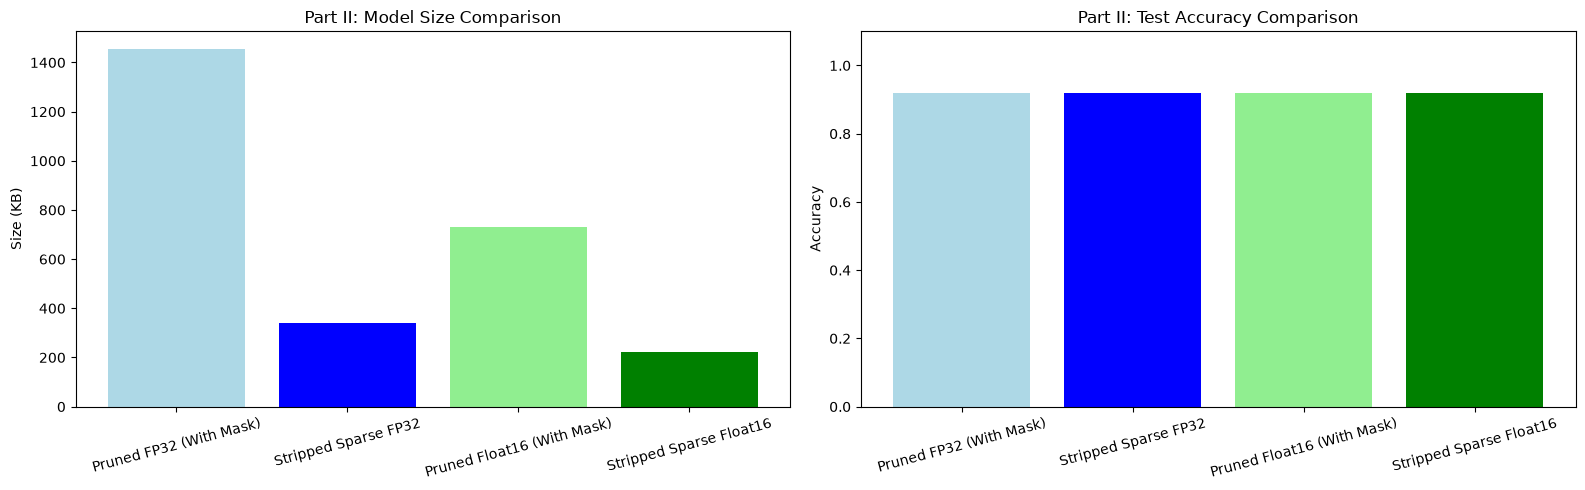

In [18]:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# Plot bar charts for Part II
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Model Sizes
ax1.bar(part2_comparison["Model"], part2_comparison["Model Size (KB)"], color=['lightblue', 'blue', 'lightgreen', 'green'])
ax1.set_title("Part II: Model Size Comparison")
ax1.set_ylabel("Size (KB)")
ax1.tick_params(axis='x', rotation=15)

# Accuracies
ax2.bar(part2_comparison["Model"], part2_comparison["Test Accuracy"], color=['lightblue', 'blue', 'lightgreen', 'green'])
ax2.set_title("Part II: Test Accuracy Comparison")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1.1)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model


Classification Report (Stripped Sparse Float16):
                    precision    recall  f1-score   support

           WALKING     0.9167    0.9536    0.9348       496
  WALKING_UPSTAIRS     0.9405    0.9066    0.9232       471
WALKING_DOWNSTAIRS     0.9167    0.9167    0.9167       420
           SITTING     0.9568    0.8126    0.8789       491
          STANDING     0.8172    0.9662    0.8854       532
            LAYING     1.0000    0.9516    0.9752       537

          accuracy                         0.9192      2947
         macro avg     0.9246    0.9179    0.9190      2947
      weighted avg     0.9244    0.9192    0.9195      2947



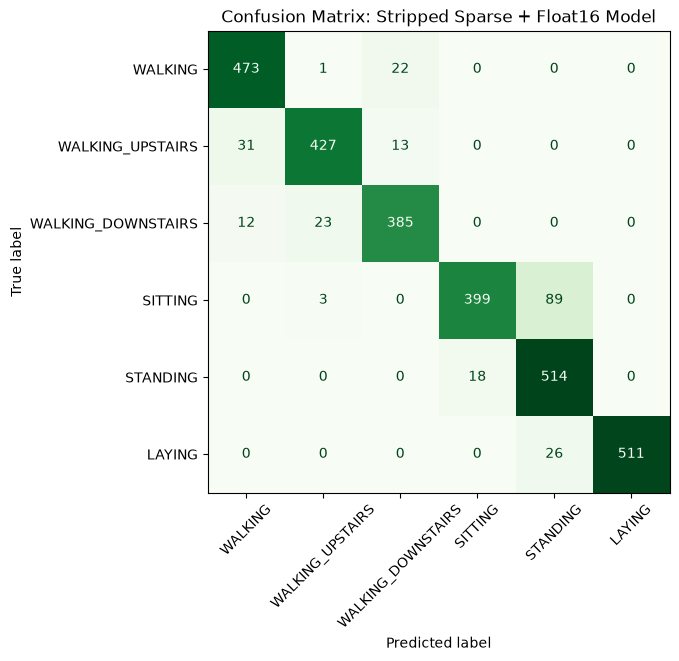

In [19]:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

print("\nClassification Report (Stripped Sparse Float16):")
print(classification_report(y_test, stripped_sparse_float16_preds, target_names=class_names, digits=4))

cm_sparse_f16 = confusion_matrix(y_test, stripped_sparse_float16_preds)
disp_sparse_f16 = ConfusionMatrixDisplay(confusion_matrix=cm_sparse_f16, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp_sparse_f16.plot(ax=ax, xticks_rotation=45, cmap="Greens", colorbar=False)
plt.title("Confusion Matrix: Stripped Sparse + Float16 Model")
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
2. Why does `strip_pruning(...)` matter before export?
3. Which model had the smallest file size in this notebook?
4. Did float16 quantization noticeably change the test accuracy?
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
